<a href="https://colab.research.google.com/github/jonshiach/graphics-book/blob/main/Flood_fill_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The flood fill algorithm

Jon Shiach

---

The flood fill algorithm fills in all pixels within a boundary starting from the pixel `(x0, y0)` on the raster array `R`. See [flood fill algorithm](https://jonshiach.github.io/graphics-book/jupyter-notebooks/1.3_Drawing_polygons.html#flood-fill-algorithm) for more details.

```
function floodfill(R, x0, y0, target, replacement)

  Q := [(x0,y0)]
  while Q is non-empty:
    (x,y) := last pixel in Q
    if R(x,y) = target:
      R(x,y) = replacement
      Append (x+1,y), (x-1,y), (x,y+1) and (x,y-1) to Q

  return R
  ``` 

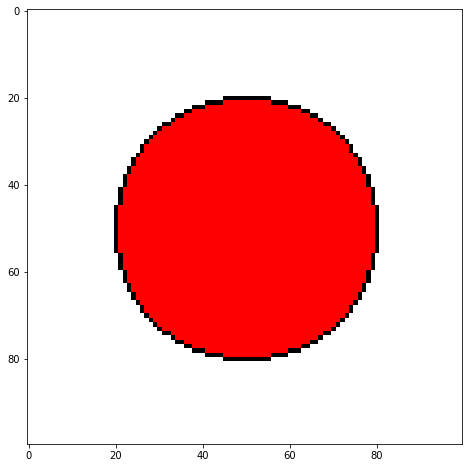

In [16]:
import numpy as np
import matplotlib.pyplot as plt


def floodfill(R, x0, y0, target, replacement):
  Q = [[x0, y0]]
  while Q:
    x, y = Q.pop(-1)
    if all(R[y, x, :] == target):
      R[y, x, :] = replacement
      Q.append([x + 1, y])
      Q.append([x - 1, y])
      Q.append([x, y + 1])
      Q.append([x, y - 1])

  return R


def drawcircle(R, cx, cy, r, colour):
  x, y, D = r, 0, 5 - 4 * r
  while y <= x:
    R[cy + y, cx + x, :] = colour
    R[cy + y, cx - x, :] = colour
    R[cy - y, cx + x, :] = colour
    R[cy - y, cx - x, :] = colour
    R[cy + x, cx + y, :] = colour
    R[cy + x, cx - y, :] = colour
    R[cy - x, cx + y, :] = colour
    R[cy - x, cx - y, :] = colour
    if D > 0:
      D += - 8 * x + 8 * y + 8
      x -= 1
    else:
      D += 8 * y + 12

    y += 1

  return R

def pixelcoords(x, y, Nx, Ny):
    xp = int(x * Nx)
    yp = int((1 - y) * Ny)
    return xp, yp


# Initialise raster array (Nx x Ny x 3 integer array of 255's)
Nx, Ny = 100, 100
R = 255 * np.ones((Ny, Nx, 3)).astype(int)

# Draw circle
R = drawcircle(R, 50, 50, 30, [0, 0, 0])

# Fill circle
x0, y0 = 50, 50
target = [255, 255, 255]
replacement = [255, 0, 0]
R = floodfill(R, x0, y0, target, replacement)

# Plot raster
fig, ax = plt.subplots(figsize=(8,8))
plt.imshow(R)
plt.show()